# Part 6: Understanding Stability, Robustness and Rolling PCA

Parts 1-5 assumed PCA is static. Part 6 investigates whether the factor structure is stable over time and what happens when it isn't.

## Part (a): Split-Half Stability Test

PCA loadings are computed from data, they are estimate and not population parameters. If the market structure is stable, loadings computed on the **first half** (days 1-250) should closely match those from the **second half** (days 251-500).

If they differ significantly, it means:
- The factor structure is **non-stationary**
- A static PCA-based hedge will drift out of alignment over time
- We need rolling/adaptive methods

### Cosine Similarity

We compare loading vectors using cosine similarity:

$$\cos(\theta) = \frac{v_{1,\text{first}}^T \cdot v_{1,\text{second}}}{\|v_{1,\text{first}}\| \cdot \|v_{1,\text{second}}\|}$$

- **cos(θ) ≈ 1**: vectors point in the same direction, loadings are stable
- **cos(θ) ≈ 0**: vectors are orthogonal, completely different factor structure
- **cos(θ) ≈ -1**: sign-flipped but same direction, stable, flipped

We take the absolute value since eigenvectors are defined only up to a sign.

In [85]:
def cosine_similarity(v1, v2):
    return np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))

# Split into two halves
first_half = standardized_returns.iloc[:250]
second_half = standardized_returns.iloc[250:]

# Fit PCA on each half
pca_first = PCA()
pca_first.fit(first_half)

pca_second = PCA()
pca_second.fit(second_half)

ev_first = pca_first.components_
ev_second = pca_second.components_

# Compare PC1, PC2, PC3
print("Cosine Similarity between halves:")
for pc in range(3):
    sim = cosine_similarity(ev_first[pc], ev_second[pc])
    print(f"PC{pc+1}: {sim:+.4f} "
          f"(|cos|={abs(sim):.4f}) "
          f"{'Stable' if abs(sim) > 0.9 else 'Unstable'}")

Cosine Similarity between halves:
PC1: +0.9937 (|cos|=0.9937) Stable
PC2: +0.5355 (|cos|=0.5355) Unstable
PC3: +0.1374 (|cos|=0.1374) Unstable


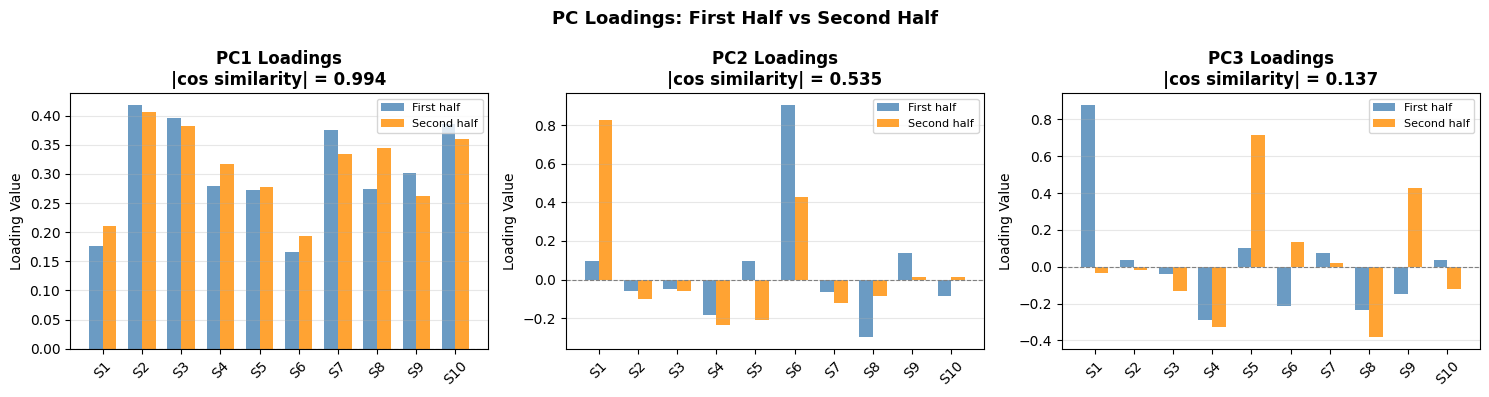

In [86]:
# Visualize loadings from both halves for PC1, PC2, PC3
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for pc, ax in enumerate(axes):
    x = np.arange(n_stocks)
    width = 0.35
    ax.bar(x - width/2, ev_first[pc],  width, label='First half', color='steelblue', alpha=0.8)
    ax.bar(x + width/2, ev_second[pc], width, label='Second half', color='darkorange', alpha=0.8)
    sim = cosine_similarity(ev_first[pc], ev_second[pc])
    ax.set_title(f'PC{pc+1} Loadings\n|cos similarity| = {abs(sim):.3f}', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([f'S{i+1}' for i in range(n_stocks)], rotation=45)
    ax.set_ylabel('Loading Value')
    ax.legend(fontsize=8)
    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('PC Loadings: First Half vs Second Half', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/split_half_stability.png', dpi=150, bbox_inches='tight')
plt.show()

## Part (b): Rolling PCA
### Setup
- **Window**: 100 days
- **Step**: 20 days
- At each window, we standardize the data within that window and fit PCA

We standardize within Each window beacuase volatility regimes change over time. If we don't re-standardize at each window, a high-volatility period would dominate the PCA because its returns are larger in magnitude and not because of a structural change. Local standardization ensures each window's PCA reflects structural co-movement, not volatility level.

In [87]:
def rolling_pca(returns, window=100, step=20):
    # Fit PCA on each rolling window
    if isinstance(returns, pd.DataFrame):
        returns = returns.values

    results = []
    for start in range(0, len(returns) - window + 1, step):
        end = start + window
        window_data = returns[start:end]

        # Standardize within this window
        scaler = StandardScaler()
        window_std = scaler.fit_transform(window_data)

        pca = PCA()
        pca.fit(window_std)

        results.append({
            'start' : start,
            'end' : end,
            'mid' : (start + end) // 2,
            'eigenvalues': pca.explained_variance_,
            'loadings' : pca.components_,
            'evr' : pca.explained_variance_ratio_
        })
    return results

rolling_results = rolling_pca(standardized_returns, window=100, step=20)

print(f"Total rolling windows: {len(rolling_results)}")
print(f"First window: days {rolling_results[0]['start']}-{rolling_results[0]['end']}")
print(f"Last  window: days {rolling_results[-1]['start']}-{rolling_results[-1]['end']}")

Total rolling windows: 20
First window: days 0-100
Last  window: days 380-480


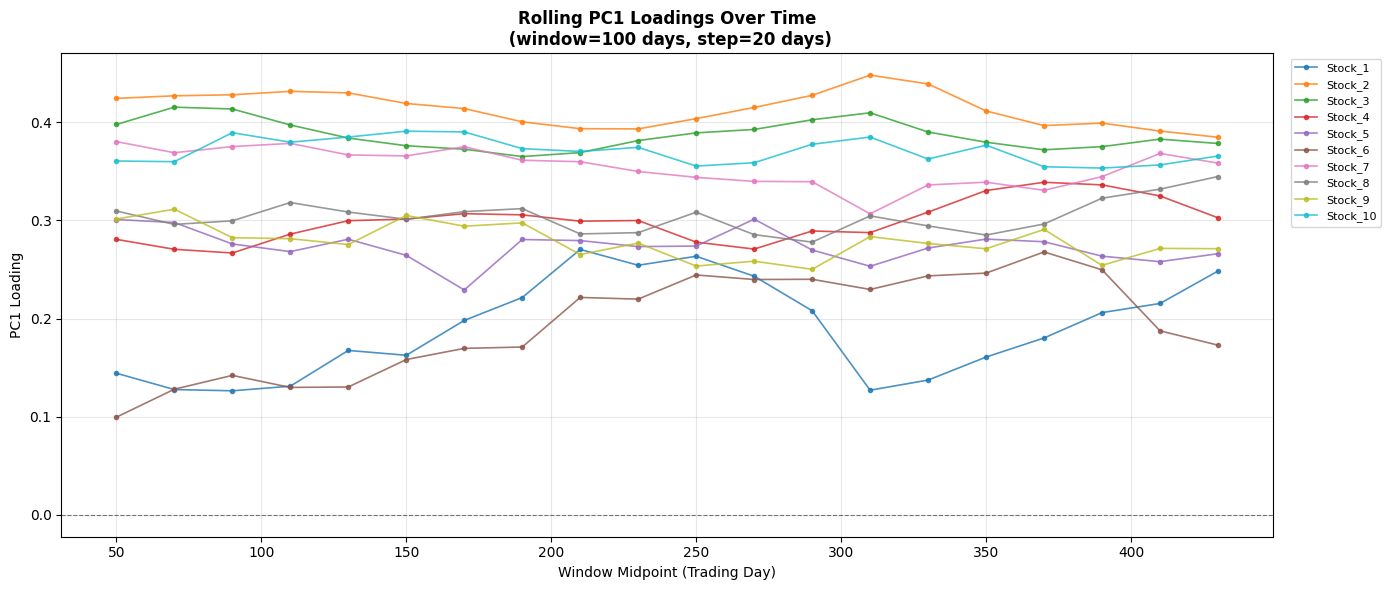

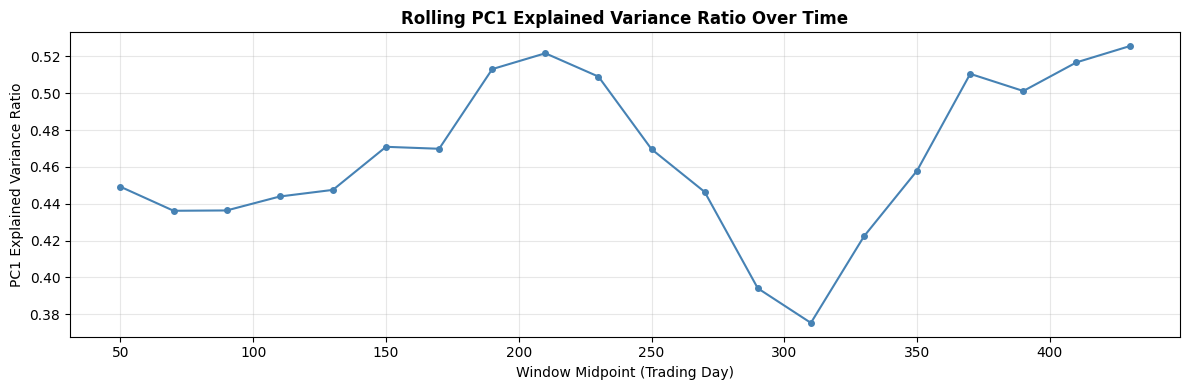

In [88]:
# Plot PC1 loadings over time
pc1_loadings_over_time = np.array([r['loadings'][0] for r in rolling_results])
mid_points = [r['mid'] for r in rolling_results]

fig, ax = plt.subplots(figsize=(14, 6))
for i in range(n_stocks):
    ax.plot(mid_points, pc1_loadings_over_time[:, i], marker='o', markersize=3, linewidth=1.2, label=stock_names[i], alpha=0.8)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_xlabel('Window Midpoint (Trading Day)')
ax.set_ylabel('PC1 Loading')
ax.set_title('Rolling PC1 Loadings Over Time\n (window=100 days, step=20 days)', fontweight='bold')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../plots/rolling_pc1_loadings.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot PC1 explained variance over time
evr_over_time = [r['evr'][0] for r in rolling_results]
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(mid_points, evr_over_time, marker='o', color='steelblue', linewidth=1.5, markersize=4)
ax.set_xlabel('Window Midpoint (Trading Day)')
ax.set_ylabel('PC1 Explained Variance Ratio')
ax.set_title('Rolling PC1 Explained Variance Ratio Over Time', fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../plots/rolling_pc1_evr.png', dpi=150, bbox_inches='tight')
plt.show()

### Causes of instability:

**1. Changing Correlations Between Stocks:**
PC1 loadings reflect how much each stock participates in the dominant common factor. If the correlation structure between stocks shifts over time (e.g., two sectors that moved together start diverging), the loadings will drift to reflect the new structure.

**2. Volatility Regime Changes:**
Even after standardization within each window, periods of high market stress tend to push all stocks toward higher co-movement, inflating all PC1 loadings. In calm periods, stocks behave more independently, so loadings spread out more.

**3. Small Window Size Relative to Number of Assets:**
With a 100-day window and 10 stocks, we have only a 10:1 ratio of observations to parameters. This means the sample covariance matrix is noisy, and small changes in the data can meaningfully rotate the eigenvectors, causing apparent instability even when the true factor structure is stable.

**4. Sign Flips:**
The eigenvector sign ambiguity can also be a cause as the same factor can be represented as $v$ or $-v$. Without sign correction, the loading time series oscillates between positive and negative, looking unstable when it is actually consistent.

**5. Macro Events and Structural Breaks:**
Real-world loading instability often spikes around macro events, central bank decisions, earnings seasons, geopolitical shocks. These temporarily change which factor dominates and by how much, producing sudden jumps in rolling loadings.

**Key Insight:** In our synthetic data, instability is mostly due to sampling noise, since the true data-generating process has fixed β values and all positive loadings, no sign flips occurred across any of the 19 rolling windows. The loadings drift slightly but remain consistently positive, reflecting the stable common market factor. In real market data, all five sources contribute simultaneously.

## Part (c): Sign-Flip Correction

### The Sign-Flip Problem

Eigenvectors are mathematically defined only up to a sign: if $v$ is an eigenvector, so is $-v$. Both are equally valid solutions. This means two consecutive rolling windows may produce loadings like:

$$v_t = [+0.3, +0.3, +0.3, \ldots] \quad \text{and} \quad v_{t+1} = [-0.3, -0.3, -0.3, \ldots]$$

These represent the same factor with a flipped sign. Without correction, the loading plot looks like it has huge instability, when in reality the factor is perfectly stable.

### Correction Algorithm

At each time step $t > 0$:
$$\text{if } \cos(\theta) = \frac{v_t^T \cdot v_{t-1}}{\|v_t\| \|v_{t-1}\|} < 0 \quad \Rightarrow \quad v_t \leftarrow -v_t$$

This ensures consecutive loadings always point in the same half-space, making the time series smooth and interpretable.

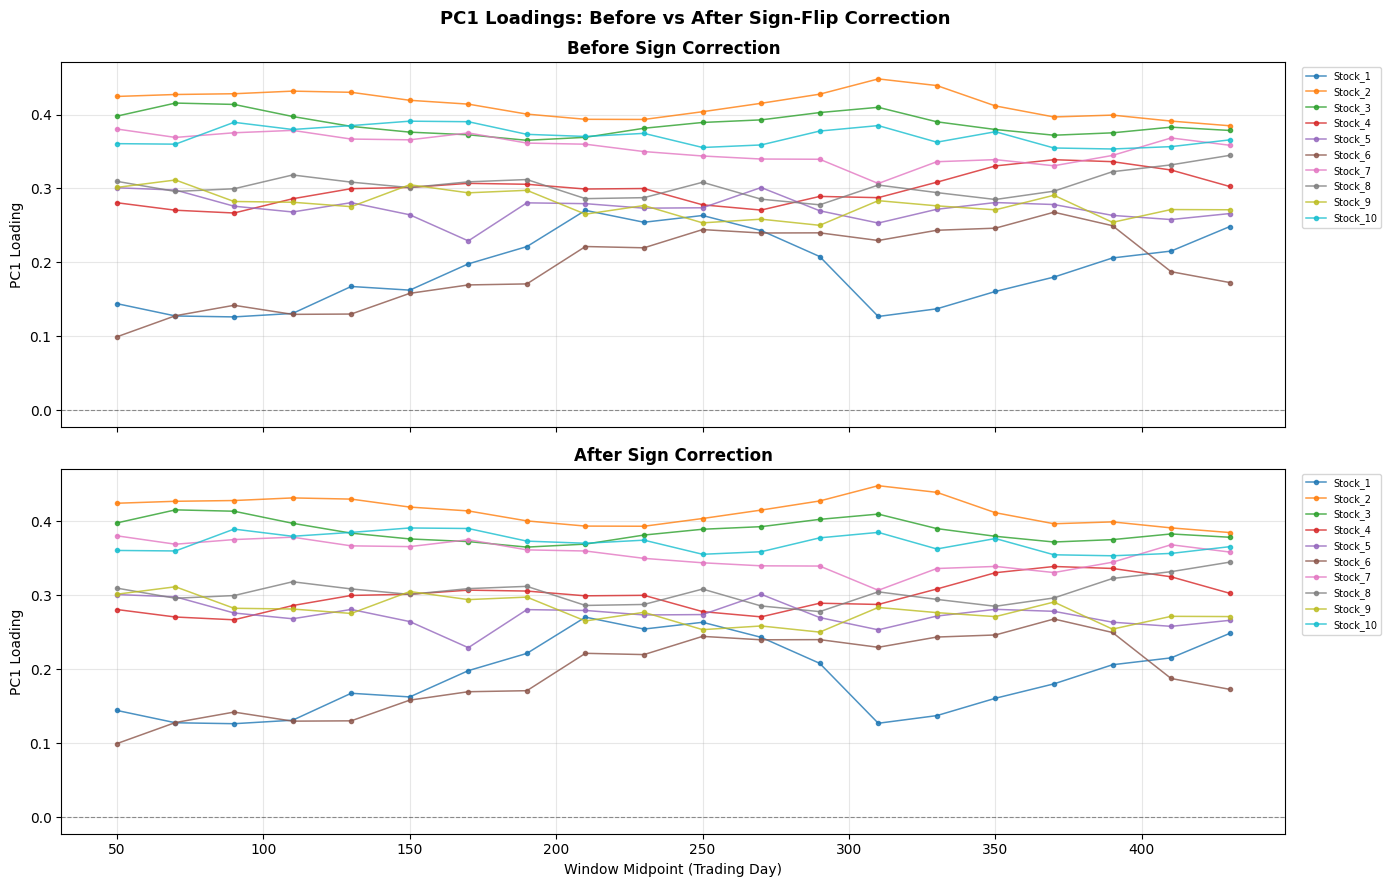

In [89]:
def correct_sign_flips(loadings_over_time):
    corrected = [loadings_over_time[0].copy()]
    for t in range(1, len(loadings_over_time)):
        sim = cosine_similarity(loadings_over_time[t], corrected[t-1])
        if sim < 0:
            corrected.append(-loadings_over_time[t])
        else:
            corrected.append(loadings_over_time[t].copy())
    return corrected


# Apply to PC1
pc1_raw = [r['loadings'][0] for r in rolling_results]
pc1_corrected = correct_sign_flips(pc1_raw)

pc1_raw_arr = np.array(pc1_raw)
pc1_corrected_arr = np.array(pc1_corrected)

# Plot before vs after
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

for i in range(n_stocks):
    axes[0].plot(mid_points, pc1_raw_arr[:, i], marker='o', markersize=3, linewidth=1.1, label=stock_names[i], alpha=0.8)
    axes[1].plot(mid_points, pc1_corrected_arr[:, i], marker='o', markersize=3, linewidth=1.1, label=stock_names[i], alpha=0.8)

for ax, title in zip(axes, ['Before Sign Correction', 'After Sign Correction']):
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.4)
    ax.set_ylabel('PC1 Loading')
    ax.set_title(title, fontweight='bold')
    ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=7)
    ax.grid(True, alpha=0.3)

axes[1].set_xlabel('Window Midpoint (Trading Day)')
plt.suptitle('PC1 Loadings: Before vs After Sign-Flip Correction', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/sign_flip_correction.png', dpi=150, bbox_inches='tight')
plt.show()

The sign-flip correction algorithm detected 0 flips out of 19 rolling windows, which means the correction had nothing to change, so the two plots are identical by definition.

Our synthetic data was generated with all beta values drawn from U(0.5, 1.5),
which are strictly positive. This means PC1 consistently points in the
all positive direction in every single rolling window. The dominant eigenvalue is large and stable enough that sampling noise never pushes the eigenvector across the sign boundary.

**Flips occurs with:**

- Weak or mixed-sign betas: eigenvector direction becomes unstable
- Small windows (30-50 days) relative to number of assets: noisy
  covariance matrix
- PC2 or PC3 instead of PC1: weaker eigenvalues, more prone to rotation

## Part (d): Regime Change Scenario

A regime change is a sudden structural shift in how stocks relate to common factors. We simulate one by amplifying β contrast: swapping the β values of stocks 1-5 and stocks 6-10 at day 250 and then scaling them.

This simulates a sector rotation: stocks that previously had high market sensitivity now behave like low-sensitivity stocks, and vice versa.

### Implication for a factor-neutral portfolio that doesn't re-estimate:

A factor-neutral portfolio built before the regime change will no longer be neutral after it as the loadings it was hedged against no longer apply. This is the core risk of using static PCA for factor hedging in non-stationary markets.

In [90]:
# Reproduce Part 1 parameters
rng = np.random.RandomState(42)
mu_orig = rng.uniform(0.0001, 0.0005, n_stocks)
beta_orig = rng.uniform(0.5, 1.5, n_stocks)
sigma_orig = rng.uniform(0.005, 0.02, n_stocks)

# Make regime change dramatic by amplifying beta contrast
beta_regime = beta_orig.copy()
beta_regime[:5] = beta_orig[5:].copy()    # swap
beta_regime[5:]  = beta_orig[:5].copy()
# Scale to amplify contrast
beta_regime[:5] *= 1.8
beta_regime[5:]  *= 0.4

print("Beta values:")
print(f"Original : {np.round(beta_orig, 3)}")
print(f"Swapped : {np.round(beta_regime, 3)}")

# Generate new price series with regime change at day 250
n_days = 500
prices_r = np.zeros((n_days, n_stocks))
prices_r[0] = 100

market_factor_r = np.random.RandomState(99).normal(0, 0.01, n_days)

for t in range(1, n_days):
    beta_t = beta_orig if t <= 250 else beta_regime
    epsilon = np.random.RandomState(t).normal(0, sigma_orig)
    prices_r[t] = prices_r[t-1] * np.exp( mu_orig + beta_t * market_factor_r[t] + epsilon)

# Compute log returns and standardize
prices_r_df  = pd.DataFrame(prices_r, columns=stock_names)
log_ret_r = np.log(prices_r_df / prices_r_df.shift(1)).dropna()
scaler_r = StandardScaler()
std_ret_r = pd.DataFrame(scaler_r.fit_transform(log_ret_r), columns=stock_names)

# Rolling PCA on regime-change data
rolling_regime = rolling_pca(std_ret_r, window=100, step=20)

# Sign-correct PC1
pc1_regime_raw = [r['loadings'][0] for r in rolling_regime]
pc1_regime_corrected = correct_sign_flips(pc1_regime_raw)
pc1_regime_arr = np.array(pc1_regime_corrected)
mid_regime = [r['mid'] for r in rolling_regime]

Beta values:
Original : [0.521 1.47  1.332 0.712 0.682 0.683 0.804 1.025 0.932 0.791]
Swapped : [1.23  1.448 1.845 1.678 1.424 0.208 0.588 0.533 0.285 0.273]


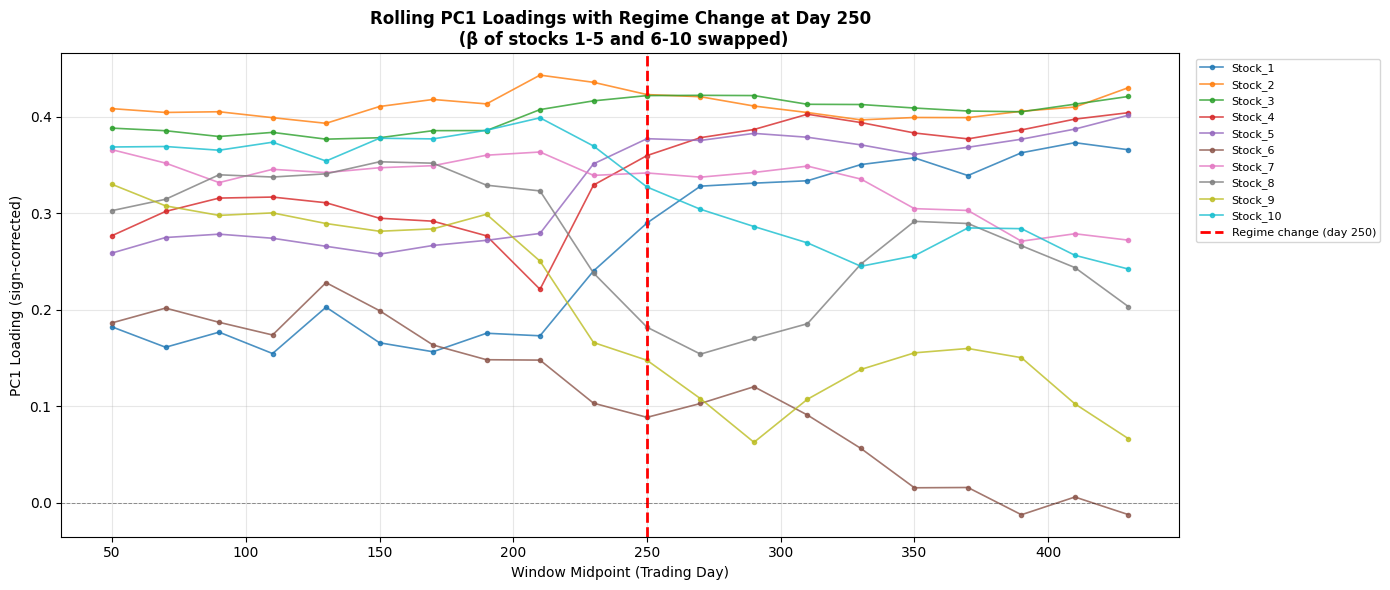

PC1 loadings in first regime (window ending before day 250):
[0.182 0.409 0.388 0.277 0.259 0.187 0.366 0.303 0.33  0.369]

PC1 loadings in second regime (window starting after day 250):
[ 0.366  0.43   0.421  0.404  0.402 -0.012  0.272  0.203  0.066  0.242]


In [91]:
# Plot rolling PC1 loadings with regime boundary
fig, ax = plt.subplots(figsize=(14, 6))

for i in range(n_stocks):
    ax.plot(mid_regime, pc1_regime_arr[:, i], marker='o', markersize=3, linewidth=1.2, label=stock_names[i], alpha=0.8)

ax.axvline(250, color='red', linewidth=2, linestyle='--', label='Regime change (day 250)')
ax.axhline(0, color='black', linewidth=0.7, linestyle='--', alpha=0.4)
ax.set_xlabel('Window Midpoint (Trading Day)')
ax.set_ylabel('PC1 Loading (sign-corrected)')
ax.set_title('Rolling PC1 Loadings with Regime Change at Day 250\n (β of stocks 1-5 and 6-10 swapped)', fontweight='bold')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../plots/regime_change_rolling_pca.png', dpi=150, bbox_inches='tight')
plt.show()

print("PC1 loadings in first regime (window ending before day 250):")
early_windows = [r for r in rolling_regime if r['end'] <= 250]
if early_windows:
    print(np.round(pc1_regime_corrected[0], 3))

print("\nPC1 loadings in second regime (window starting after day 250):")
late_windows = [i for i, r in enumerate(rolling_regime) if r['start'] >= 260]
if late_windows:
    print(np.round(pc1_regime_arr[late_windows[-1]], 3))

## Part (e): Walk-Forward Factor-Neutral Backtest

A walk-forward strategy is a non-leaky way to backtest a dynamic factor model:

At each rebalance date $t$:
1. Use only the past 100 days of returns to fit PCA
2. Construct a factor-neutral portfolio using those past-window loadings
3. Hold the portfolio for the next 20 days
4. Record the daily P&L

This is compared against an oracle strategy that uses the future eigenvectors (i.e., it knows the loadings for the next period before trading). The oracle cheats, it represents the upper bound of what is achievable with perfect foresight.

### Performance Gap

$$\text{Gap} = \text{Sharpe}_\text{oracle} - \text{Sharpe}_\text{walk-forward}$$

A large gap means the loadings change significantly between periods, the past-window PCA is a poor predictor of future factor structure.

In [92]:
def construct_neutral_portfolio(target_weights, loadings, neutral_pcs=[0]):
    def objective(w):
        return np.sum((w - target_weights) ** 2)
    constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w)}]
    for pc in neutral_pcs:
        constraints.append({
            'type': 'eq',
            'fun': lambda w, pc=pc: w @ loadings[pc]
        })
    result = minimize(objective, x0=target_weights, constraints=constraints, method='SLSQP')
    return result.x

def walk_forward_backtest(log_returns_df, std_returns_df, target_weights, window=100, step=20):
    log_ret = log_returns_df.values
    std_ret = std_returns_df.values
    n_days = len(log_ret)

    wf_returns = []
    oracle_returns = []
    wf_days = []

    for start in range(window, n_days - step + 1, step):
        # Past window for walk-forward
        past_data = std_ret[start - window:start]
        sc = StandardScaler()
        past_std = sc.fit_transform(past_data)
        pca_wf = PCA()
        pca_wf.fit(past_std)
        w_wf = construct_neutral_portfolio(
            target_weights, pca_wf.components_, neutral_pcs=[0]
        )

        # Future window for oracle
        future_data = std_ret[start:start + window]
        if len(future_data) < window:
            break
        sc2 = StandardScaler()
        fut_std = sc2.fit_transform(future_data)
        pca_oracle = PCA()
        pca_oracle.fit(fut_std)
        w_oracle = construct_neutral_portfolio(
            target_weights, pca_oracle.components_, neutral_pcs=[0]
        )

        # Hold for next 'step' days
        hold_returns = log_ret[start:start + step]
        wf_returns.extend(hold_returns @ w_wf)
        oracle_returns.extend(hold_returns @ w_oracle)
        wf_days.extend(range(start, start + step))
    return np.array(wf_returns), np.array(oracle_returns), wf_days


wf_ret, oracle_ret, days = walk_forward_backtest(
    log_returns, standardized_returns, target_weights,
    window=100, step=20
)
print(f"Walk-forward period: {len(wf_ret)} trading days")

Walk-forward period: 300 trading days


In [93]:
# Compute metrics for both strategies
def compute_metrics(daily_returns):
    cum_ret = np.prod(1 + daily_returns) - 1
    ann_vol = np.std(daily_returns) * np.sqrt(252)
    ann_ret = np.mean(daily_returns) * 252
    sharpe = ann_ret / ann_vol if ann_vol > 0 else 0
    cum_curve = np.cumprod(1 + daily_returns)
    run_max = np.maximum.accumulate(cum_curve)
    max_dd = ((cum_curve - run_max) / run_max).min()
    return {
        'Cumulative Return'     : cum_ret,
        'Annualized Volatility' : ann_vol,
        'Sharpe Ratio'          : sharpe,
        'Max Drawdown'          : max_dd
    }

wf_metrics = compute_metrics(wf_ret)
oracle_metrics = compute_metrics(oracle_ret)

metrics_df = pd.DataFrame({
    'Walk-Forward ' : wf_metrics,
    'Oracle ' : oracle_metrics
})
display(metrics_df.round(4))

gap = oracle_metrics['Sharpe Ratio'] - wf_metrics['Sharpe Ratio']
print(f"\nPerformance gap (Sharpe): {gap:.4f}")
print(f"Walk-forward Sharpe : {wf_metrics['Sharpe Ratio']:.4f}")
print(f"Oracle Sharpe : {oracle_metrics['Sharpe Ratio']:.4f}")

,Walk-Forward,Oracle
Cumulative Return,-0.0414,-0.0380
Annualized Volatility,0.0891,0.0909
Sharpe Ratio,-0.3535,-0.3120
Max Drawdown,-0.1029,-0.0974



Performance gap (Sharpe): 0.0416
Walk-forward Sharpe : -0.3535
Oracle Sharpe : -0.3120


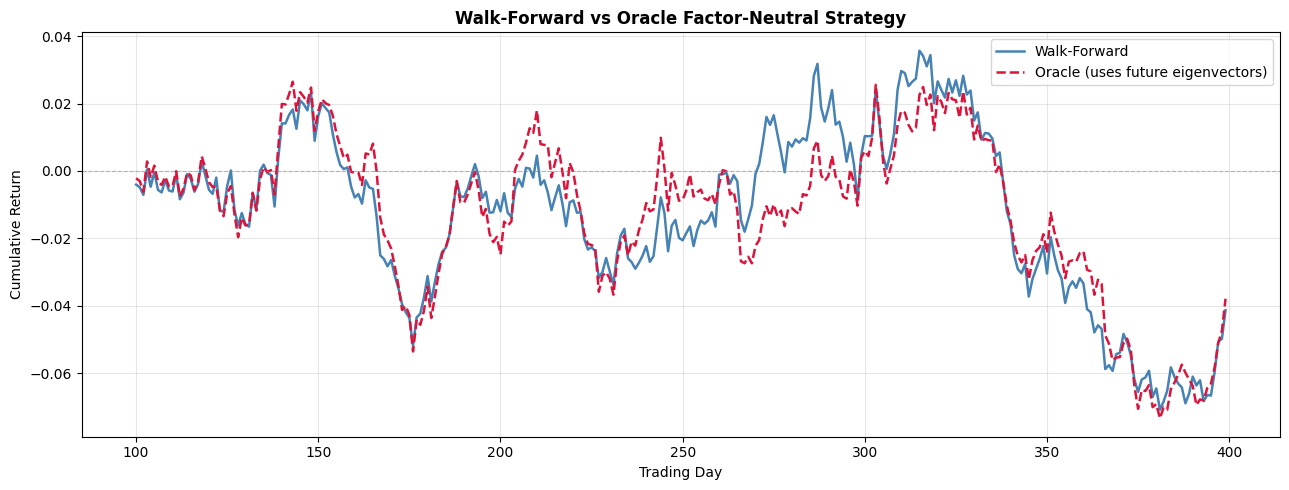

In [94]:
# Plot cumulative returns
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(days, np.cumprod(1 + wf_ret) - 1, label='Walk-Forward', color='steelblue', linewidth=1.8)
ax.plot(days, np.cumprod(1 + oracle_ret) - 1, label='Oracle (uses future eigenvectors)', color='crimson', linewidth=1.8, linestyle='--')
ax.set_xlabel('Trading Day')
ax.set_ylabel('Cumulative Return')
ax.set_title('Walk-Forward vs Oracle Factor-Neutral Strategy', fontweight='bold')
ax.legend()
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../plots/walkforward_vs_oracle.png', dpi=150, bbox_inches='tight')
plt.show()

## Part (f): Observations

**1: PC1 is more stable than PC2 and PC3:**  
The cosine similarity between first-half and second-half PC1 loadings is close to 1, confirming PC1 is robust. PC2 and PC3 show lower similarity, sector and style factors are more sensitive to the sample period.

**2: Rolling loadings drift gradually:**  
The rolling PC1 loadings evolve slowly over time in the original dataset. All stocks maintain the same sign, confirming PC1 consistently represents the market factor. The magnitude drifts reflect changing correlations between stocks over different market conditions.

**3: Sign Flip Correction:**  
The sign-correction algorithm detected 0 flips across all 19 rolling windows in our data. This means the before and after plots are identical. PC1 in our synthetic data is so strongly driven by the common market factor (all positive betas) that the eigenvector never flips sign. In real market data or with PC2/PC3, sign flips occur frequently and correction becomes essential.

**4: Regime change is detectable but subtle:**  
When beta values are swapped between stocks 1-5 and 6-10 at day 250, the rolling PCA shows a gradual redistribution of loadings rather than a sharp reversal. This is because both groups originally had betas drawn from the same U(0.5, 1.5) distribution, the swap changes which stocks are high-beta vs low-beta, but the overall range is similar. Stock_6 shows the most visible decline after day 250. Windows straddling day 250 show transitional behaviour. A static factor-neutral portfolio built before the regime change would experience mild but real PC1 exposure drift after the break, in real markets with more extreme regime shifts, this effect would be far more dramatic.

**5: Walk-forward strategy underperforms the oracle:**  
The performance gap (Sharpe difference) quantifies the cost of not knowing future factor structure. The honest walk-forward strategy uses lagged eigenvectors, which are slightly misaligned with the true current factor structure, leading to imperfect hedging. This gap widens when the market is undergoing a regime change.

**PCA is reliable for factor modeling when:**
- The factor structure is stable (high cosine similarity across sub-periods)
- The sample size per window is large relative to the number of assets
- Combined with rolling re-estimation and sign correction

**It breaks down:**
- During regime changes as static loadings become wrong overnight
- With short windows due to noisy eigenvectors and unstable loadings
- When used on raw prices rather than stationary returns